## Figures for CASA007 Lecture 2 

This nb generates the figures for Lecture 2 - Exploratory Data Analysis. All figs generated are saved to the folder 'L2_images'. 

In [3]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random
from matplotlib.animation import FuncAnimation
import pandas as pd

from matplotlib.patches import Rectangle, Ellipse
from PIL import Image
from io import BytesIO

import numpy as np

from scipy.stats import norm

## Stick figure sampling 

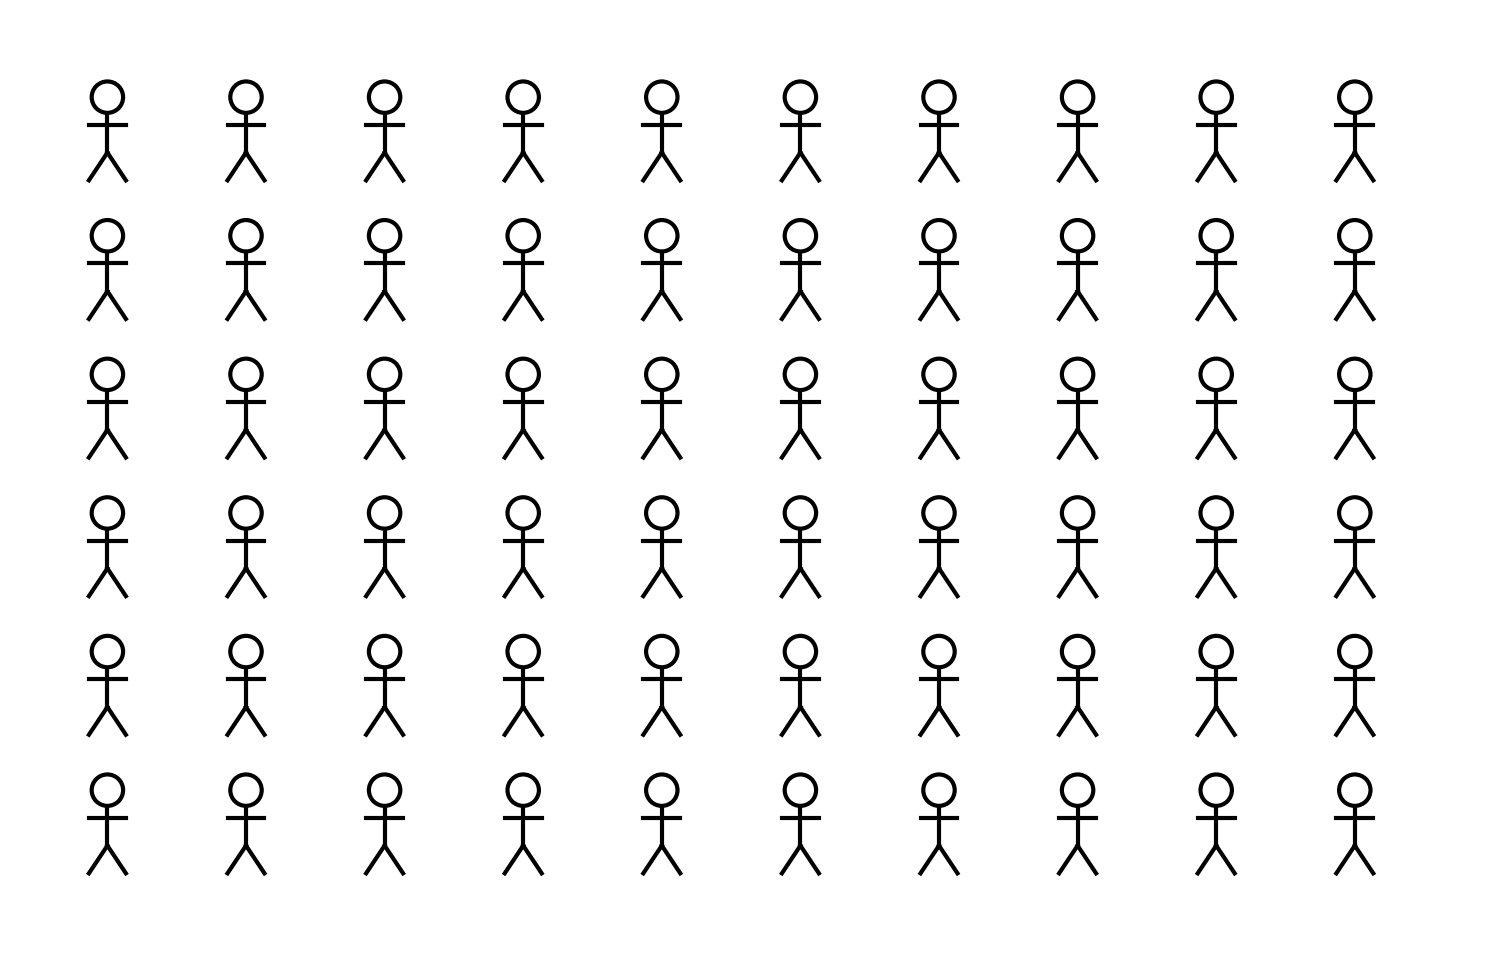

In [28]:
x_pos = 10
y_pos = 6

sample = 10

# --- Stick figure drawing function ---
def draw_stick_figure(ax, x, y, color="black"):
    """Draw a stick figure centered at (x,y)."""
    head_radius = 0.17
    # head
    ax.add_patch(plt.Circle((x, y+0.6), head_radius, fill=False, color=color, lw=2))
    # body
    ax.plot([x, x], [y, y+0.4], color=color, lw=2)
    # arms
    ax.plot([x-0.2, x+0.2], [y+0.3, y+0.3], color=color, lw=2)
    # legs
    ax.plot([x, x-0.2], [y, y-0.3], color=color, lw=2)
    ax.plot([x, x+0.2], [y, y-0.3], color=color, lw=2)

# --- Grid of positions (10 x 10) with spacing ---
spacing = 1.5  # increase to spread out figures
positions = [(i*spacing, j*spacing) for j in range(y_pos) for i in range(x_pos)]
N = len(positions)

# --- Animation setup ---
fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
ax.set_aspect("equal")
ax.set_xlim(-1, x_pos*spacing)
ax.set_ylim(-1, y_pos*spacing)
ax.axis("off")

# number of frames per phase
black_frames = 8   # ~2 seconds if interval=300 ms
highlight_frames = 3
back_to_black_frames = 8
cycle_length = black_frames + highlight_frames + back_to_black_frames

# store the current highlighted set
current_highlighted = []

def random_update(frame):
    global current_highlighted
    phase = frame % cycle_length
    
    ax.clear()
    ax.set_aspect("equal")
    ax.set_xlim(-1, x_pos*spacing)
    ax.set_ylim(-1, y_pos*spacing)
    ax.axis("off")
    
    # pick new sample only at the start of the highlight phase
    if phase == black_frames:
        current_highlighted = random.sample(range(N), sample)
    elif phase >= black_frames + highlight_frames:
        current_highlighted = []  # back to full black grid
    
    for idx, (x, y) in enumerate(positions):
        if idx in current_highlighted:
            draw_stick_figure(ax, x, y, color="#e16fca")
        else:
            draw_stick_figure(ax, x, y, color="black")
    return []

fig.patch.set_alpha(0)       # figure background
ax.set_facecolor("none")     # axes background

ani = animation.FuncAnimation(
    fig, random_update, frames=300, interval=500, blit=False, repeat=True
)

ani.save("L2_images/stickfigures.gif", writer="pillow", fps=2, savefig_kwargs={"transparent": True})

In [29]:
def biased_update(frame):
    global current_highlighted
    phase = frame % cycle_length
    
    ax.clear()
    ax.set_aspect("equal")
    ax.set_xlim(-1, x_pos*spacing)
    ax.set_ylim(-1, y_pos*spacing)
    ax.axis("off")
    
    # top row indices
    top_row_indices = list(range(10))  # 0 to 9
    
    # pick new sample only at the start of the highlight phase
    if phase == black_frames:
        current_highlighted = random.sample(top_row_indices, 10)  # highlight all in top row
    elif phase >= black_frames + highlight_frames:
        current_highlighted = []  # back to full black grid
    
    for idx, (x, y) in enumerate(positions):
        if idx in current_highlighted:
            draw_stick_figure(ax, x, y, color="#e16fca")
        else:
            draw_stick_figure(ax, x, y, color="black")
    return []

fig.patch.set_alpha(0)       # figure background
ax.set_facecolor("none")     # axes background

ani = animation.FuncAnimation(
    fig, biased_update, frames=300, interval=500, blit=False, repeat=True
)

ani.save("L2_images/stickfigures_biased.gif", writer="pillow", fps=2, savefig_kwargs={"transparent": True})

## Anscombe's quartet

In [77]:
anscombe = {
    "I": {
        "x": [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0],
        "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    },
    "II": {
        "x": [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0],
        "y": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    },
    "III": {
        "x": [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0],
        "y": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    },
    "IV": {
        "x": [8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 19.0, 8.0, 8.0, 8.0],
        "y": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
    },
}

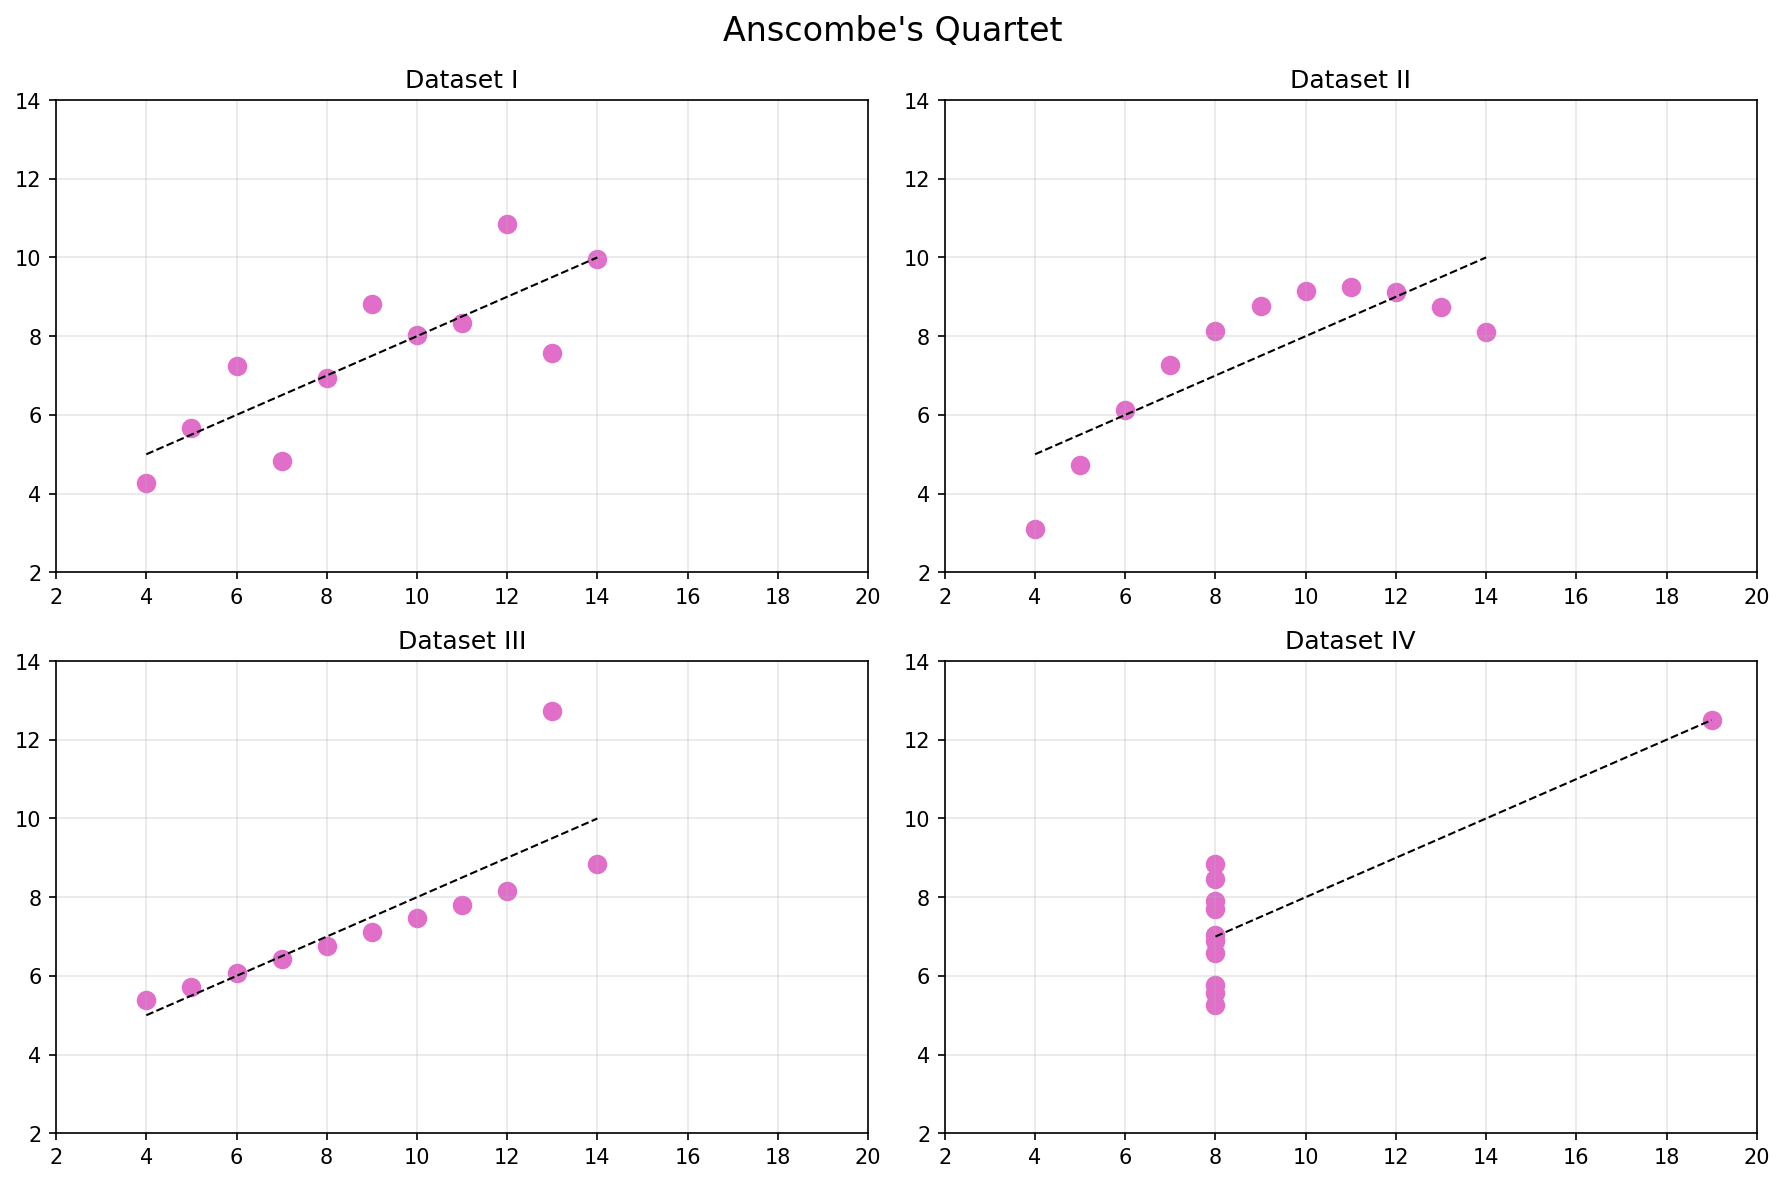

In [82]:
# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)
axes = axes.flatten()

for i, (key, data) in enumerate(anscombe.items()):
    ax = axes[i]
    ax.scatter(data["x"], data["y"], color="#e16fca", s=70)
    
    # Add regression line (simple linear fit)
    m, b = np.polyfit(data["x"], data["y"], 1)
    x_fit = np.linspace(min(data["x"]), max(data["x"]), 100)
    ax.plot(x_fit, m * x_fit + b, color="black", linestyle="--", linewidth=1)
    
    ax.set_title(f"Dataset {key}")
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)
    ax.grid(True, alpha=0.3)

plt.suptitle("Anscombe's Quartet", fontsize=16)
plt.tight_layout()
plt.savefig("L2_images/anscombes_four.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Normal distribution

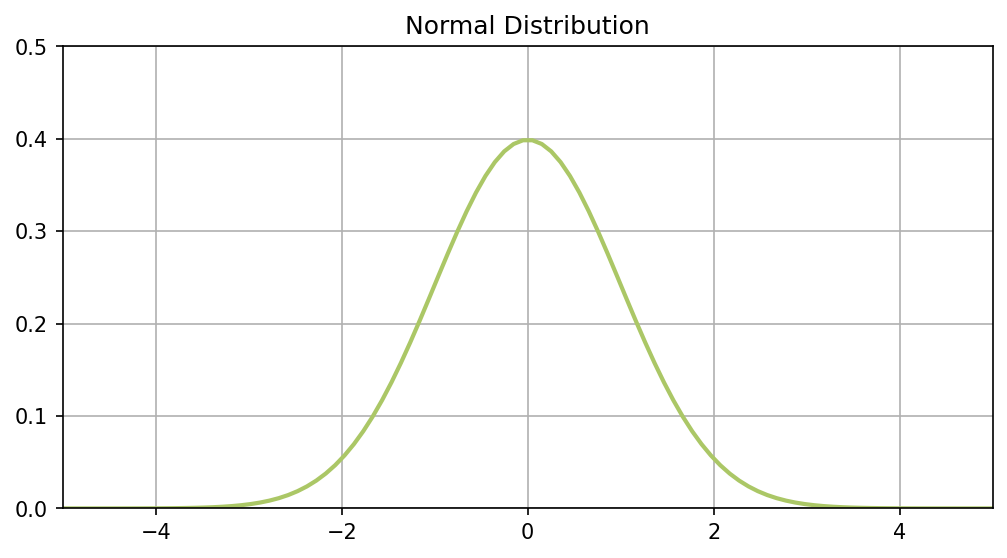

In [35]:
# plot a normal distribution in colour #abc766
x = np.linspace(-5, 5, 100)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(x, y, color="#abc766", lw=2)
plt.title('Normal Distribution')
# plt.xlabel('Z-score')
# plt.ylabel('Probability Density')
plt.grid(True)

plt.xlim(-5, 5)
plt.ylim(0, 0.5)

plt.savefig("L2_images/normal_distribution.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

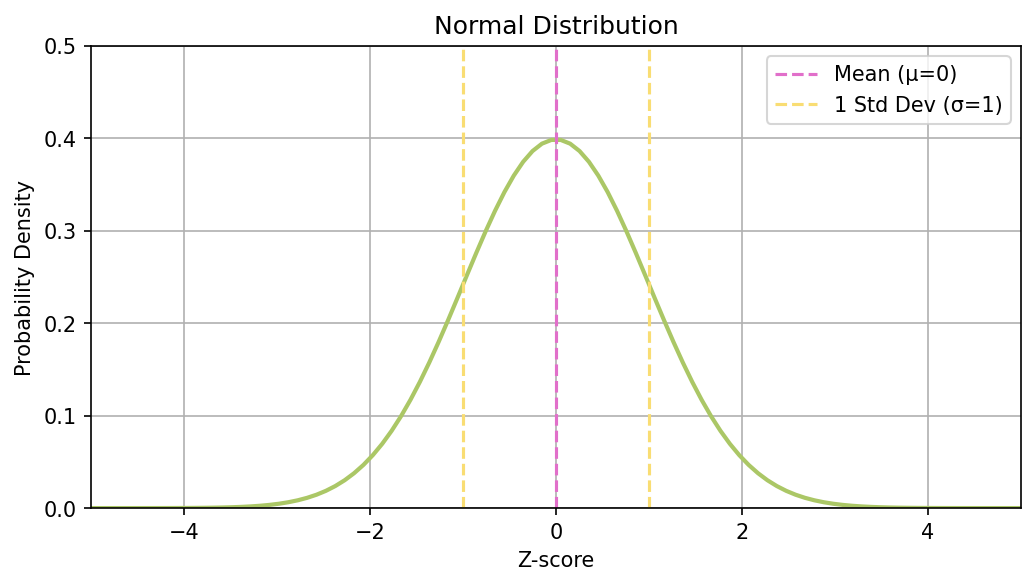

In [36]:
# plot a normal distribution in colour #abc766 - with lines showing the mean and standard deviation 
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 100)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(x, y, color="#abc766", lw=2)
plt.title('Normal Distribution')
plt.xlabel('Z-score')
plt.ylabel('Probability Density')
plt.grid(True)

# add mean and standard deviation lines
mean = 0
std_dev = 1
plt.axvline(mean, color="#e16fca", linestyle='--', label='Mean (μ=0)')
plt.axvline(mean + std_dev, color="#f9dd73", linestyle='--', label='1 Std Dev (σ=1)')
plt.axvline(mean - std_dev, color="#f9dd73", linestyle='--')
plt.legend()
plt.xlim(-5, 5)
plt.ylim(0, 0.5)

plt.savefig("L2_images/normal_distribution_annotated.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

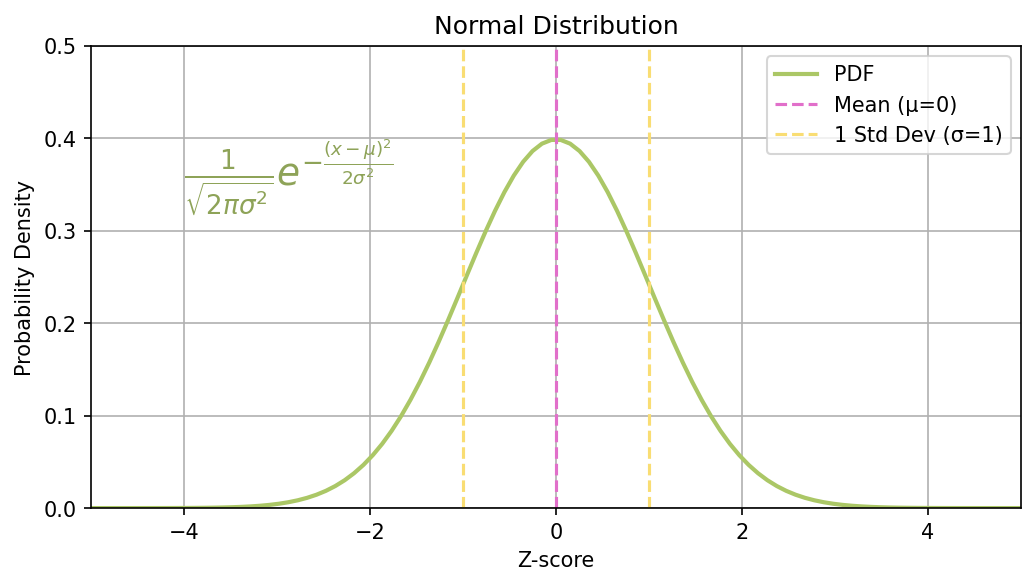

In [64]:
# plot a normal distribution in colour #abc766 - with lines showing the mean and standard deviation 
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 100)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(x, y, color="#abc766", lw=2, label='PDF')
plt.title('Normal Distribution')
plt.xlabel('Z-score')
plt.ylabel('Probability Density')
plt.grid(True)

# add mean and standard deviation lines
mean = 0
std_dev = 1
plt.axvline(mean, color="#e16fca", linestyle='--', label='Mean (μ=0)')
plt.axvline(mean + std_dev, color="#f9dd73", linestyle='--', label='1 Std Dev (σ=1)')
plt.axvline(mean - std_dev, color="#f9dd73", linestyle='--')
plt.legend()
plt.xlim(-5, 5)
plt.ylim(0, 0.5)

# write the pdf \frac{1}{\sqrt{2 \pi \sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}} on the plot
plt.text(-4, 0.35, r"$\frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$", fontsize=18, fontweight="bold", color="#8EA358")

plt.savefig("L2_images/normal_distribution_pdf.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

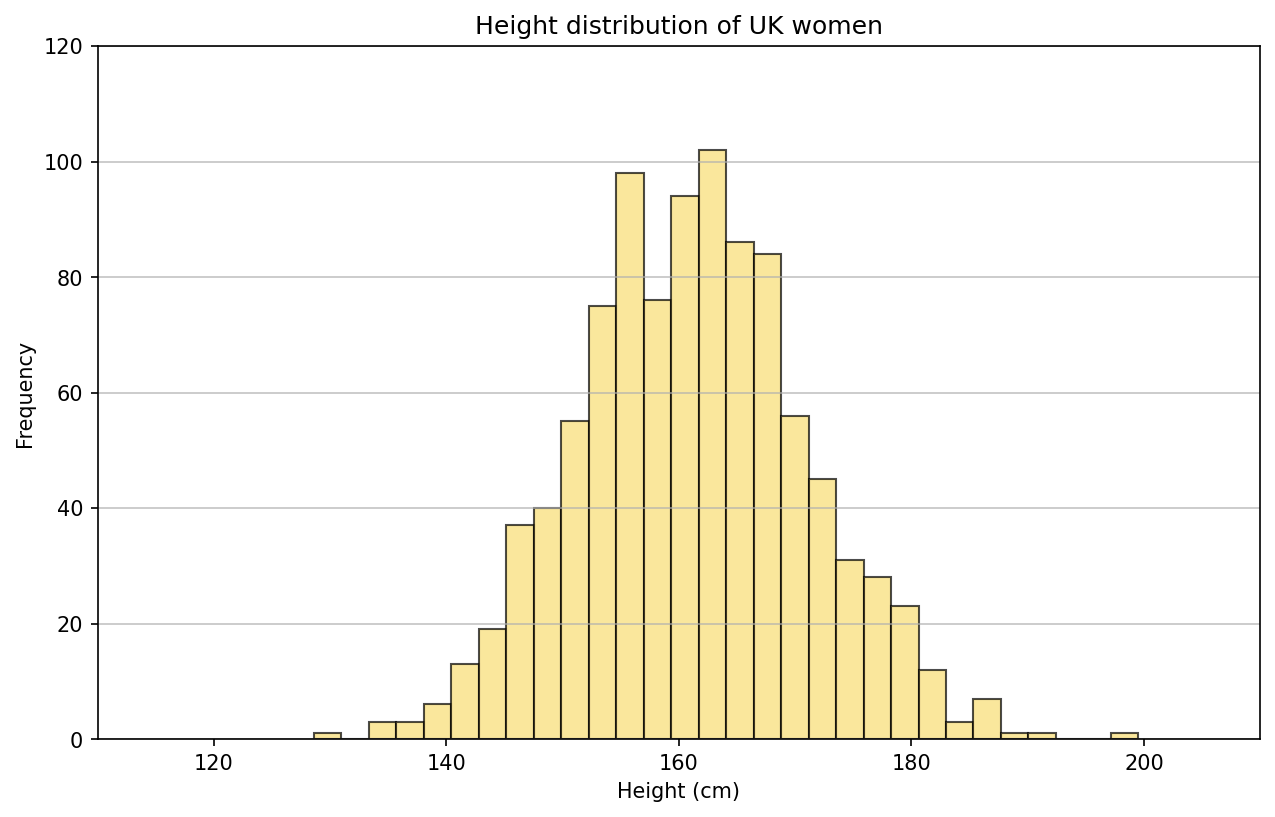

In [2]:
# generate a histogram of a normal distribution of human height in cm 

np.random.seed(42)  # for reproducibility
heights = np.random.normal(loc=161, scale=10, size=1000)
plt.figure(figsize=(10, 6), dpi=150)
plt.hist(heights, bins=30, color="#f9dd73", edgecolor="black", alpha=0.7)
plt.title('Height distribution of UK women')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xlim(110, 210)
plt.ylim(0, 120)
plt.savefig("L2_images/height_histogram.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [4]:
# save heights to csv
df = pd.DataFrame(heights, columns=["Height_cm"])
df.to_csv("L2_images/heights.csv", index=False)

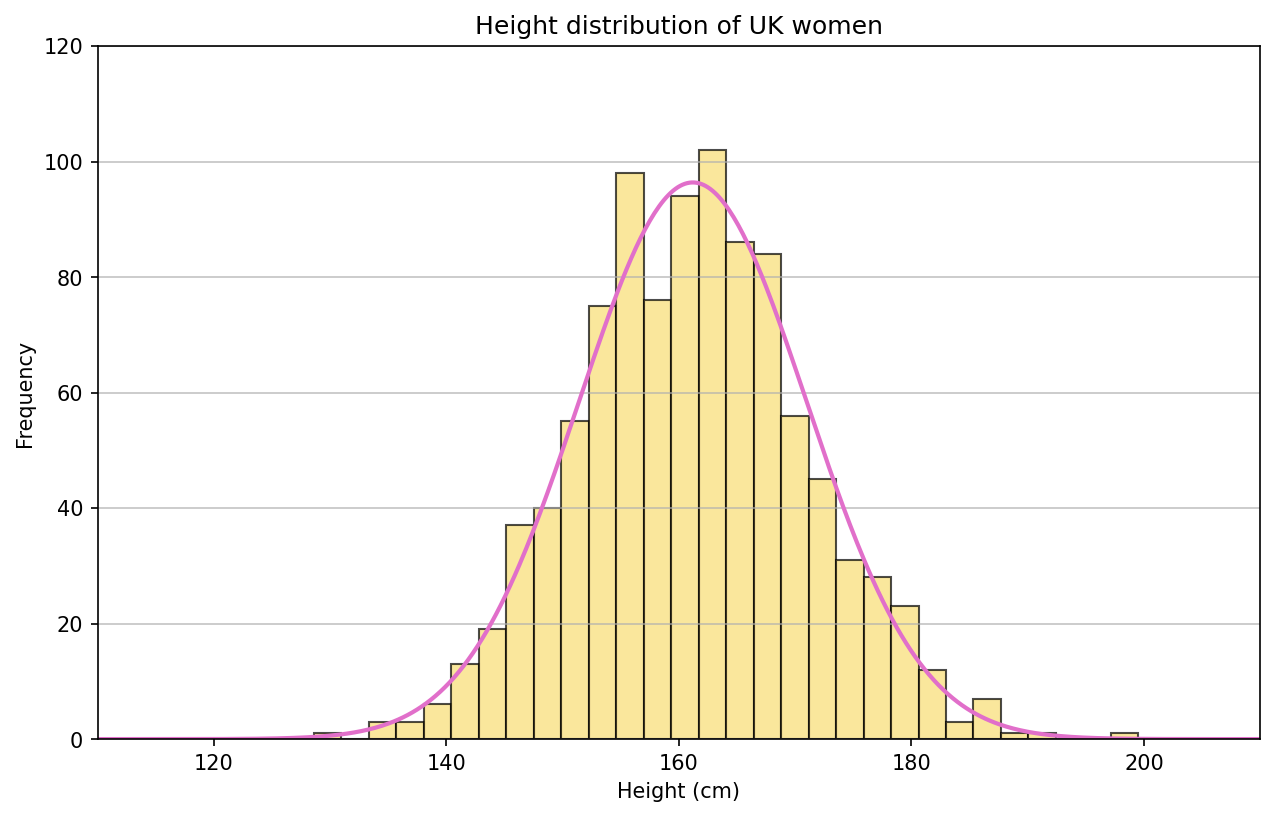

In [70]:
np.random.seed(42)
heights = np.random.normal(loc=161, scale=10, size=1000)

# Histogram parameters
bins = 30
hist_values, bin_edges = np.histogram(heights, bins=bins)

bin_width = bin_edges[1] - bin_edges[0]

plt.figure(figsize=(10, 6), dpi=150)

# Plot histogram
plt.hist(heights, bins=bins, color="#f9dd73", edgecolor="black", alpha=0.7)

# Compute Gaussian PDF scaled to histogram
mu = np.mean(heights)
sigma = np.std(heights)
x_vals = np.linspace(110, 210, 500)
pdf = norm.pdf(x_vals, mu, sigma) * len(heights) * bin_width

# Plot PDF
plt.plot(x_vals, pdf, color="#e16fca", linewidth=2)

plt.title("Height distribution of UK women")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.xlim(110, 210)
plt.ylim(0, 120)
plt.savefig("L2_images/height_histogram_pdf.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()


## Exponentials 

chessboard with 'grains of rice' 

In [ ]:
board_size = 8
squares_to_animate = 12

# Number of grains on each square
grains = [2**i for i in range(squares_to_animate)]

frames = []

def draw_rice(ax, x, y, count):
    # Fixed rice size
    grain_width = 0.08
    grain_height = 0.03
    grains_per_row = 8
    for i in range(count):
        rx = i % grains_per_row
        ry = i // grains_per_row
        gx = x + 0.05 + rx * (grain_width + 0.02)
        gy = y + 1 - 0.05 - ry * (grain_height + 0.02)
        grain = Ellipse((gx, gy), width=grain_width, height=grain_height, color='#f9dd73')
        ax.add_patch(grain)

for step in range(squares_to_animate):
    fig, ax = plt.subplots(figsize=(6,6))

    # Draw border
    border_thickness = 0.1
    ax.add_patch(Rectangle(
        (-border_thickness, -border_thickness),
        board_size + 2*border_thickness,
        board_size + 2*border_thickness,
        facecolor="#6E4E38"
    ))

    # Draw chessboard squares
    for i in range(board_size):
        for j in range(board_size):
            color = 'white' if (i+j) % 2 == 0 else 'black'
            ax.add_patch(Rectangle((i, j), 1, 1, facecolor=color))

    # Add rice grains
    for s in range(step+1):
        x = s % board_size
        y = board_size - 1 - (s // board_size)
        draw_rice(ax, x, y, grains[s])

    ax.set_xlim(-border_thickness, board_size + border_thickness)
    ax.set_ylim(-border_thickness, board_size + border_thickness)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    fig.patch.set_alpha(0)       # figure background
    ax.set_facecolor("none")     # axes background

    # Save to in-memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, transparent=True)
    buf.seek(0)
    frame = Image.open(buf)
    frames.append(frame)
    plt.close()

# Save final GIF
frames[0].save(
    'L2_images/chessboard_rice.gif',
    format='GIF',
    append_images=frames[1:],
    save_all=True,
    duration=800,
    loop=1,
    transparency=0
)

static chessboard

In [18]:
board_size = 8

# Total grains per square: 1, 2, 4, 8, ..., 2**63
grains = [2**i for i in range(board_size*board_size)]

fig, ax = plt.subplots(figsize=(8,8))

# Draw border
border_thickness = 0.1
ax.add_patch(Rectangle(
    (-border_thickness, -border_thickness),
    board_size + 2*border_thickness,
    board_size + 2*border_thickness,
    facecolor="#6E4E38"
))

# Draw chessboard squares and numbers
for s in range(board_size*board_size):
    x = s % board_size
    y = board_size - 1 - (s // board_size)  # top-left start
    
    # Chessboard square color
    color = 'white' if (x + (board_size - 1 - y)) % 2 == 0 else 'black'
    ax.add_patch(Rectangle((x, y), 1, 1, facecolor=color))
    
    # Format number: normal or scientific notation
    if grains[s] <= 10_000_000:
        label = f"{grains[s]:,}"
    else:
        label = f"{grains[s]:.2e}"  # e.g., 1.07e10
        # Convert to 'y x10^n' format
        base, exp = label.split('e')
        label = f"{float(base):.2f}×10^{int(exp)}"
    
    ax.text(
        x + 0.5, y + 0.5, label,
        color='black' if color == 'white' else 'white',
        ha='center', va='center', fontsize=8
    )

ax.set_xlim(-border_thickness, board_size + border_thickness)
ax.set_ylim(-border_thickness, board_size + border_thickness)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

# Save as PNG
plt.savefig('L2_images/chessboard_numbers.png', dpi=200, transparent=True)
plt.close()

Increasing numbers chessboard 

In [ ]:
board_size = 8
grains = [2**i for i in range(board_size * board_size)]
frames = []

def format_grains(n):
    """Format number normally or in scientific notation."""
    if n <= 10_000_000:
        return f"{n:,}"
    else:
        label = f"{n:.2e}"  # e.g., 1.07e10
        base, exp = label.split('e')
        return f"{float(base):.2f}×10^{int(exp)}"

def draw_board(ax):
    """Draw chessboard with border (but no numbers)."""
    border_thickness = 0.1
    
    # Border
    ax.add_patch(Rectangle(
        (-border_thickness, -border_thickness),
        board_size + 2*border_thickness,
        board_size + 2*border_thickness,
        facecolor="#6E4E38"
    ))

    # Squares
    for i in range(board_size):
        for j in range(board_size):
            color = 'white' if (i+j) % 2 == 0 else 'black'
            ax.add_patch(Rectangle((i, j), 1, 1, facecolor=color))

# --- Generate frames ---
for step in range(board_size * board_size):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw board
    draw_board(ax)

    # Add numbers progressively
    for s in range(step + 1):
        x = s % board_size
        # y = s // board_size  # bottom-left = first row
        y = board_size - 1 - (s // board_size)
        square_color = 'white' if (x + y) % 2 == 0 else 'black'
        label = format_grains(grains[s])

        ax.text(
            x + 0.5, y + 0.5, label,
            color='black' if square_color == 'white' else 'white',
            ha='center', va='center', fontsize=12 if grains[s] <= 100_000 else 8
        )

    # Formatting
    border_thickness = 0.1
    ax.set_xlim(-border_thickness, board_size + border_thickness)
    ax.set_ylim(-border_thickness, board_size + border_thickness)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # Save frame to memory
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, transparent=True)
    buf.seek(0)
    frames.append(Image.open(buf))
    plt.close()

# --- Save GIF ---
frames[0].save(
    "L2_images/chessboard_numbers.gif",
    save_all=True,
    append_images=frames[1:],
    duration=800,   # ms per frame
    loop=1          # play once
)

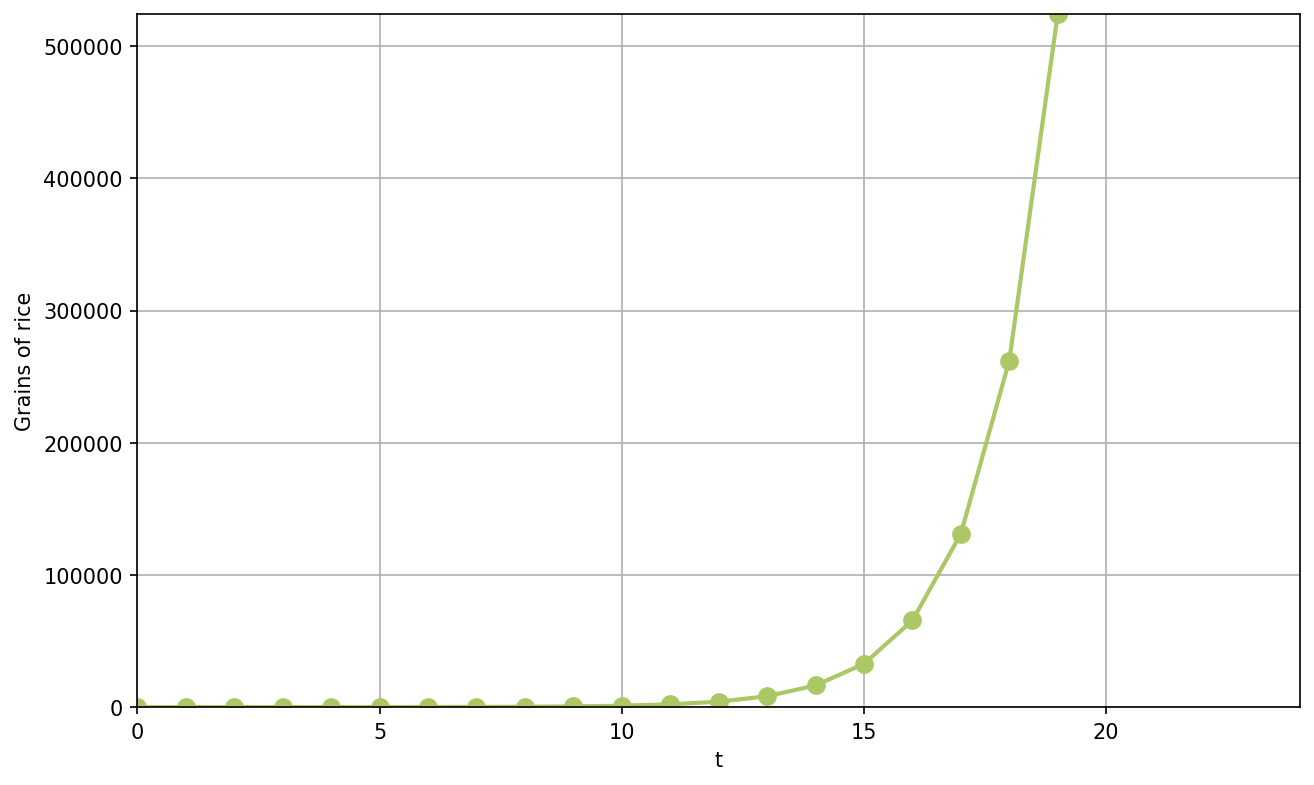

In [2]:
# Parameters
N0 = 1         # initial number of grains of rice
doubling_days = 1
num_points = 20  # number of points to show

# Generate discrete time points (every 7 days)
t_points = np.arange(0, doubling_days * num_points, doubling_days)
N_points = N0 * 2**(t_points // doubling_days)

# Set up figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
line, = ax.plot([], [], 'o-', color="#abc766", linewidth=2, markersize=8)
ax.set_xlim(0, t_points[-1] + 5)
ax.set_ylim(0, N_points[-1])
ax.set_xlabel("t")
ax.set_ylabel("Grains of rice")
# ax.set_title("")
ax.grid(True)

# Animation update function
def update(frame):
    # Show points up to current frame
    x_data = t_points[:frame + 1]
    y_data = N_points[:frame + 1]
    line.set_data(x_data, y_data)
    return line,

fig.patch.set_alpha(0)       # figure background
ax.set_facecolor("none")     # axes background

# Create animation
ani = FuncAnimation(fig, update, frames=len(t_points), interval=500, blit=True, repeat=True)

# To save as GIF
ani.save("L2_images/discrete_exponential_chess.gif", writer="pillow", savefig_kwargs={"transparent": True})

plt.show()



/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_83989/200099255.py:3: RuntimeWarning: divide by zero encountered in log
  y = np.log(x)


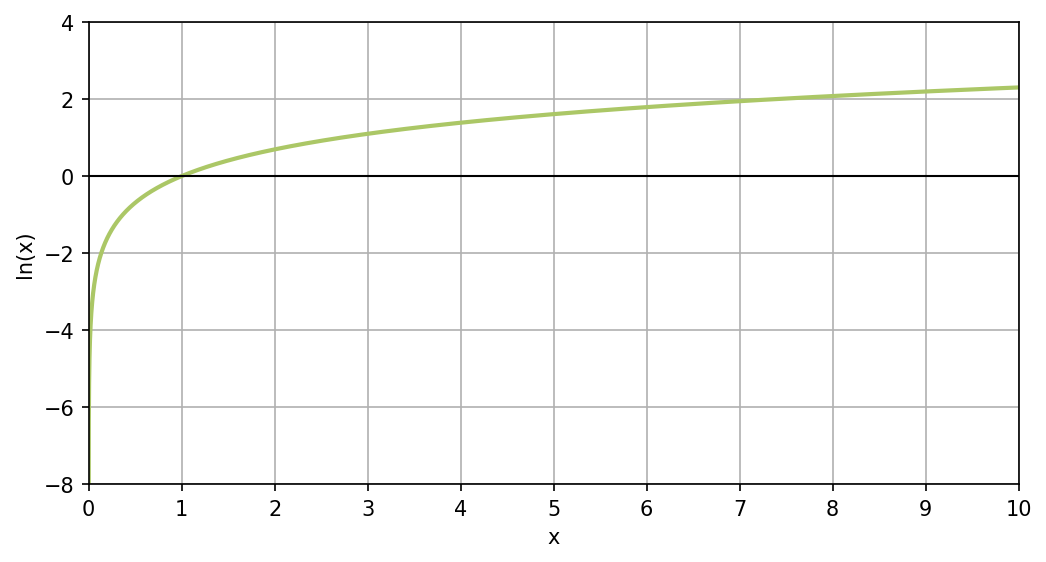

In [20]:
# Plot the natural logarithm 
x = np.linspace(0, 10, 100000)
y = np.log(x)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(x, y, color="#abc766", lw=2)
plt.axhline(0, color="black", lw=1)  # horizontal line at y=0

plt.xlabel('x')
plt.ylabel('ln(x)')
plt.grid(True)

# Ticks at every integer on the x-axis
plt.xticks(range(0, 11))

plt.xlim(0, 10)
plt.ylim(-8, 4)

plt.savefig("L2_images/natural_logarithm.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()
